# Business Performance Overview



Olist is one of Brazil's largest e-commerce marketplaces, connecting thousands of sellers with customers across the country.

The goal of this analysis is to evaluate overall business performance by analyzing sales trends, revenue growth, geographic performance, operational efficiency, and customer satisfaction.


## Business Questions
1. Is the business growing over time?

2. How has revenue changed over time?

3. Which product categories generate the highest revenue?

4. Which states generate the most revenue?

5. How efficient is the delivery process?

6. How satisfied are customers?



## Import Libraries

In [1]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

## Load data

In [2]:
project_id = "brazilian-e-com-dataset-olist"
client = bigquery.Client(project=project_id)

**Notes:** Only orders with order status 'delivered' are included to measure completed business transactions. Orders with other statuses (e.g. canceled or unavailable) are excluded because they do not represent successfully completed sales.

## Is the business growing over time?

In [3]:
query = """
select
    date_trunc(date(order_purchase_timestamp), month) AS month,
    count(order_id) as total_orders
from `brazilian-e-com-dataset-olist.Olist.olist_orders_dataset`
where order_status = 'delivered'
group by month
order by month
"""
df_orders_growth = client.query(query).to_dataframe()
df_orders_growth.head()

,month,total_orders
0,2016-09-01,1
1,2016-10-01,265
2,2016-12-01,1
3,2017-01-01,750
4,2017-02-01,1653


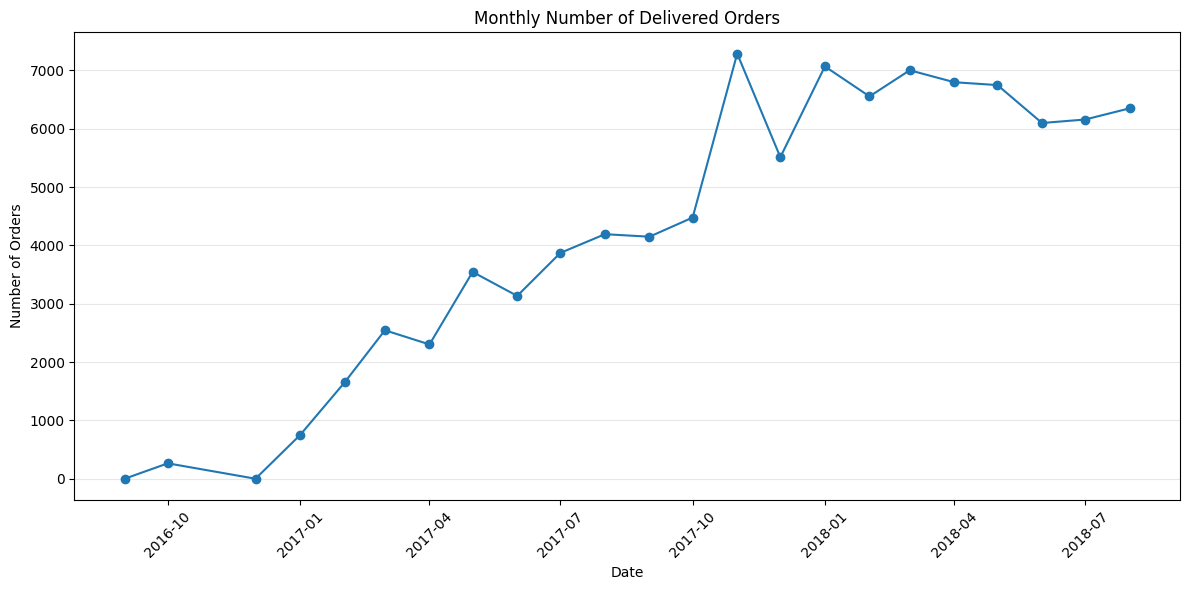

In [4]:
plt.figure(figsize=(12, 6))

plt.plot(df_orders_growth["month"], df_orders_growth["total_orders"], marker="o")

plt.title("Monthly Number of Delivered Orders")
plt.xlabel("Date")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:** Monthly figures for completed orders show a steady upward trend throughout the period under review, indicating stable business growth. Two significant spikes in order volume were observed in early 2017 and in November 2017. Although these peaks may be related to seasonal demand or promotional campaigns, the available data does not allow us to determine their exact cause. It is noteworthy that after both peaks, the monthly order volume remained higher than before, indicating that the business maintained its growth momentum rather than reverting to previous levels. The lower order volume in the final month is likely due to incomplete data and should not be interpreted as a decline without further validation.

**Recommendation** Analyze the business factors underlying periods of rapid growth in order volume. If this growth was driven by successful marketing campaigns, seasonal demand, pricing strategies, or operational improvements, assess whether these initiatives can be replicated and scaled in the future. As part of this further analysis, you should also identify which factors contributed to maintaining higher order volumes after each period of growth.


## How has revenue changed over time?

In [5]:
query = """
select
    date_trunc(date(o.order_purchase_timestamp), month) as month,
    sum(oi.price) as revenue
from `brazilian-e-com-dataset-olist.Olist.olist_orders_dataset` o
join `brazilian-e-com-dataset-olist.Olist.olist_order_items_dataset` oi
on o.order_id = oi.order_id
where o.order_status = 'delivered'
group by month
order by month
"""
df_revenue_growth = client.query(query).to_dataframe()
df_revenue_growth.head()

,month,revenue
0,2016-09-01,134.97
1,2016-10-01,40325.11
2,2016-12-01,10.90
3,2017-01-01,111798.36
4,2017-02-01,234223.40


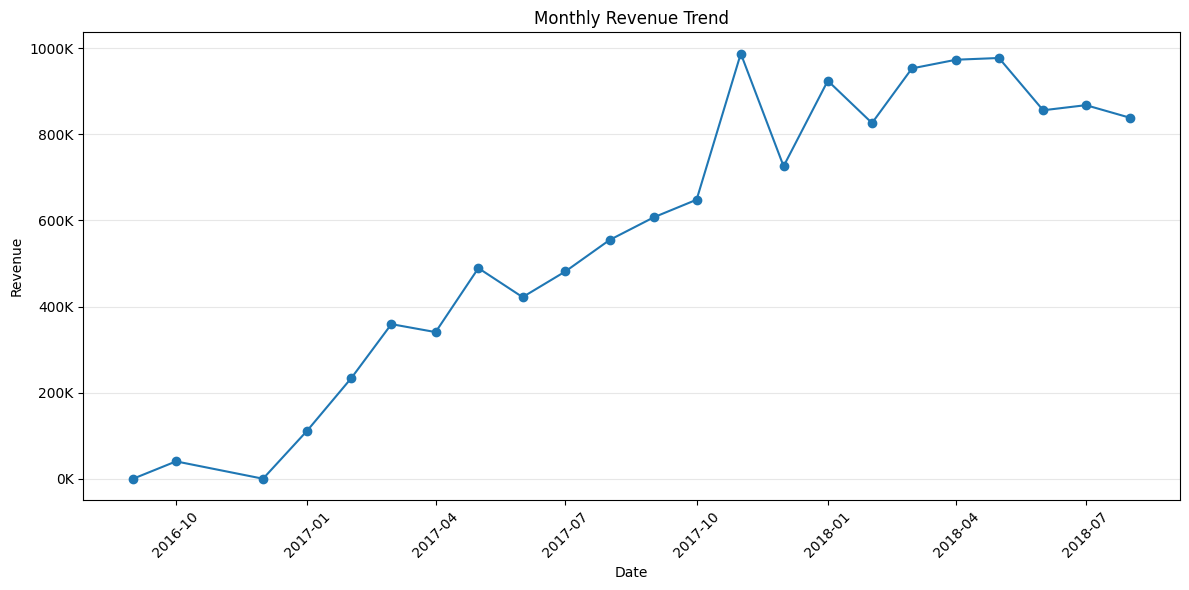

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(df_revenue_growth["month"], df_revenue_growth["revenue"], marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

ax = plt.gca()
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

**Insight:** Monthly revenue shows the same positive trend as the number of completed orders, indicating that business growth is accompanied by a proportional increase in revenue. Revenue peaked in Nov 2017 and has since remained at a higher level, indicating sustainable business expansion rather than temporary growth. Although seasonal demand or promotional campaigns may have contributed to these peaks, there is insufficient data to determine the exact cause.

**Recommendation:** Analyze the key factors that influenced periods of significant growth, and identify which initiatives contributed most to increases in both order volume and revenue. If you can identify successful strategies, consider scaling them up or reusing them during future peak seasons.

## Which product categories generate the highest revenue?

In [7]:
query = """
select c.product_category_name_english as category, round(sum(oi.price),2) as revenue
from `Olist.olist_orders_dataset` o
join `Olist.olist_order_items_dataset` oi
on  o.order_id = oi.order_id
join `Olist.olist_products_dataset` p
on oi.product_id = p.product_id
join `Olist.product_category_translation` c
on p.product_category_name = c.product_category_name
where o.order_status = 'delivered'
group by category
order by revenue desc
"""
df_revenue_cat = client.query(query).to_dataframe()
df_revenue_cat.head()

,category,revenue
0,health_beauty,1233131.72
1,watches_gifts,1166176.98
2,bed_bath_table,1023434.76
3,sports_leisure,954852.55
4,computers_accessories,888724.61


In [8]:
df_10cat = df_revenue_cat.head(10).copy()
df_10cat["category"] = df_10cat["category"].str.replace("_", " ").str.title()
df_10cat

,category,revenue
0,Health Beauty,1233131.72
1,Watches Gifts,1166176.98
2,Bed Bath Table,1023434.76
3,Sports Leisure,954852.55
4,Computers Accessories,888724.61
5,Furniture Decor,711927.69
6,Housewares,615628.69
7,Cool Stuff,610204.10
8,Auto,578966.65
9,Toys,471286.48


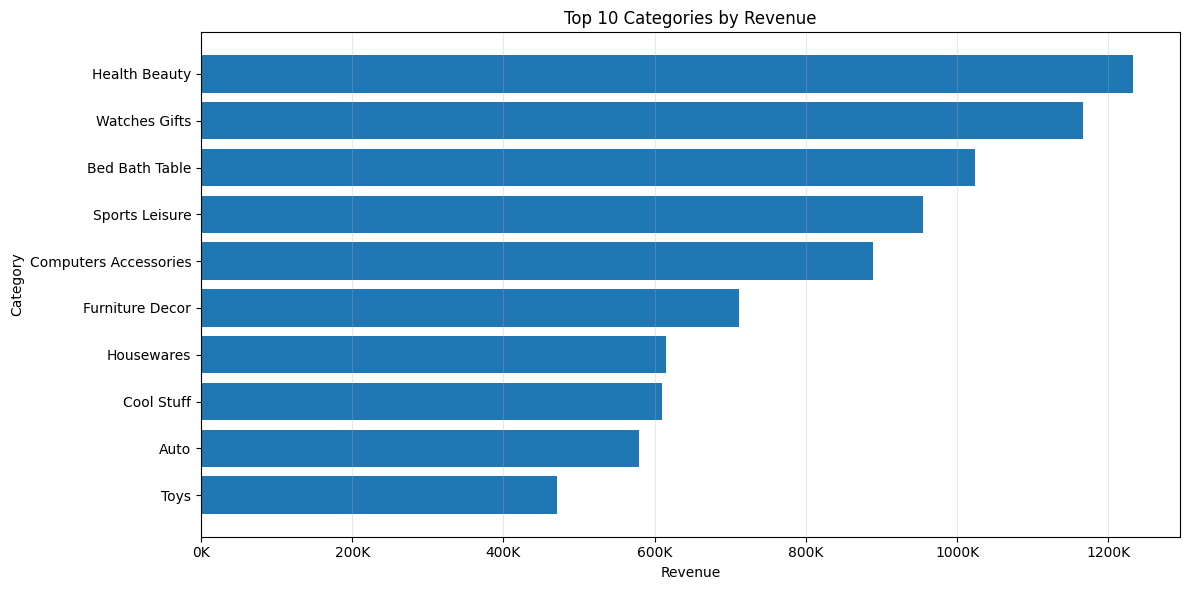

In [9]:
plt.figure(figsize=(12, 6))

plt.barh(df_10cat["category"], df_10cat["revenue"])

plt.title("Top 10 Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.grid(axis="x", alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**Insight:** "Health Beauty" is the top-revenue category, generating approximately 1.23M, followed by "Watches Gifts" (1.17M) and "Bed, Bath and Table" (1.02M).

The top categories show a relatively strong concentration of revenue: "Health Beauty", "Watches Gifts", "Bed, Bath and Table", "Sports Leisure" and "Computers Accessories" are the five leading categories.

Revenue from categories besides the leading ones declines significantly, indicating that a relatively small group of categories generate a disproportionately large share of total revenue.

**Recommendation:** Prioritize high-performing categories, such as "Health Beauty", "Watches Gifts", and "Bed, Bath and Table" by ensuring higher inventory levels and running promotions.

Analyze the factors affecting the performance of top-performing categories to identify products and pricing strategies that can be applied to other categories.

Analyze lower-performing categories to identify if they require promotions, changes to the product mix or a reduction in inventory investment.

## Which states generate the most revenue?

In [10]:
query = """
select customer_state, round(sum(price), 2) as revenue
from `Olist.olist_orders_dataset` o
join `Olist.olist_order_items_dataset` oi
on o.order_id = oi.order_id
join `Olist.olist_customers_dataset` c
on o.customer_id = c.customer_id
where order_status = 'delivered'
group by customer_state
order by revenue desc
"""
states = client.query(query).to_dataframe()
states.head()

,customer_state,revenue
0,SP,5067633.16
1,RJ,1759651.13
2,MG,1552481.83
3,RS,728897.47
4,PR,666063.51


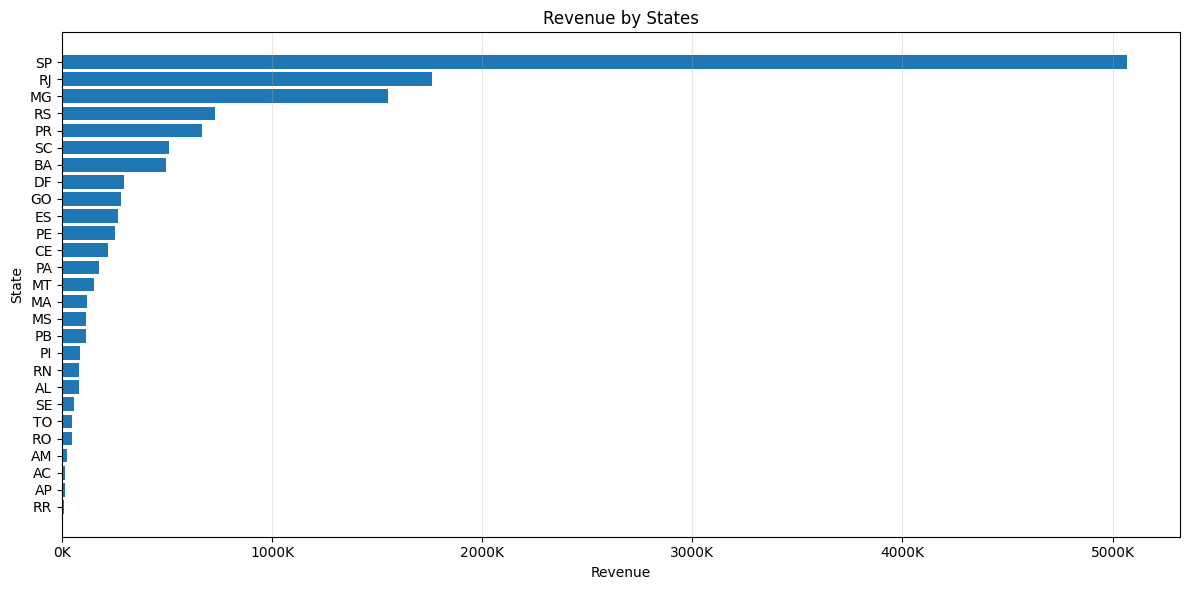

In [11]:
plt.figure(figsize=(12, 6))

plt.barh(states["customer_state"], states["revenue"])

plt.title("Revenue by States")
plt.xlabel("Revenue")
plt.ylabel("State")

plt.grid(axis="x", alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [12]:
states["share"] = (states["revenue"] / states["revenue"].sum() * 100).round(2)
states.head()

,customer_state,revenue,share
0,SP,5067633.16,38.33
1,RJ,1759651.13,13.31
2,MG,1552481.83,11.74
3,RS,728897.47,5.51
4,PR,666063.51,5.04


**Insight:** Revenue is largely concentrated in a small number of states. Sao Paulo (SP) is the dominant market, accounting for a significantly larger share of total revenue - 38%. Rio de Janeiro (RJ) and Minas Gerais (MG) rank second and third, but their contributions are significantly lower, at 13% and 11%, respectively. This distribution indicates that the business relies heavily on a few key regional markets rather than ensuring an even distribution of revenue across the country.

**Recommendation:** Continue to strengthen the company's presence in the top-performing states, while identifying opportunities to increase market share in regions with lower performance. Future analysis should assess whether regional differences in revenue are driven by customer concentration, purchasing behavior or operational factors.

## How efficient is the delivery process?

In [13]:
query = """
select date_trunc(date(order_purchase_timestamp), month) as month,
    round(avg(date_diff(date(order_delivered_customer_date), date(order_purchase_timestamp), day)), 2) as delivery_days
from `Olist.olist_orders_dataset`
where order_status = 'delivered'
group by month
order by month
"""
delivery = client.query(query).to_dataframe()
delivery.head()

,month,delivery_days
0,2016-09-01,55.00
1,2016-10-01,19.63
2,2016-12-01,5.00
3,2017-01-01,12.75
4,2017-02-01,13.30


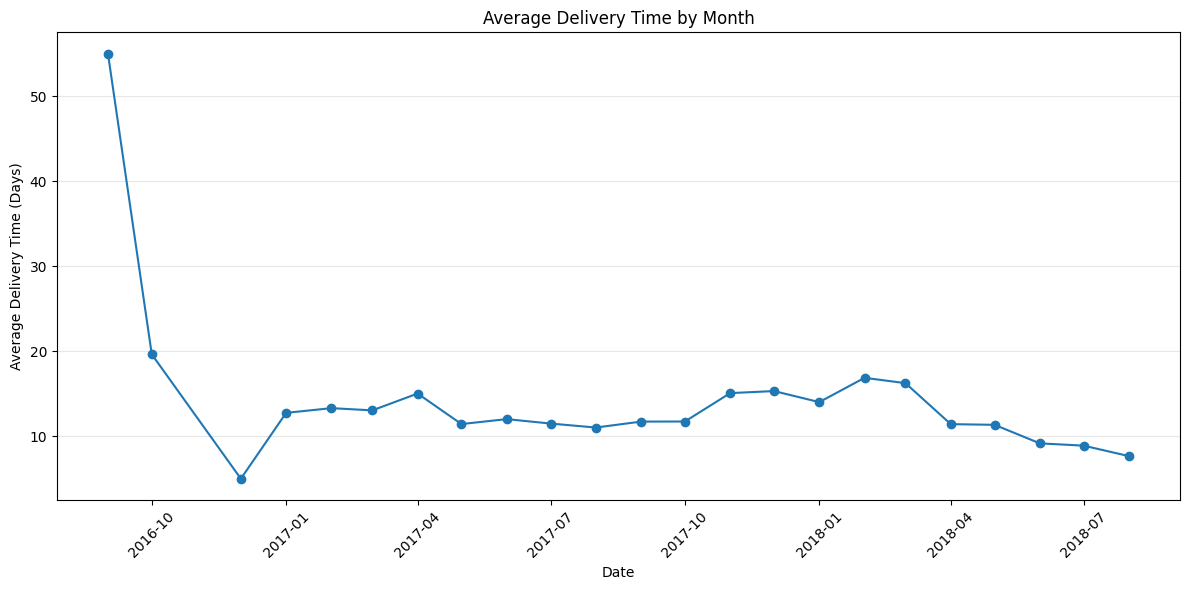

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(delivery["month"], delivery["delivery_days"], marker="o")

plt.title("Average Delivery Time by Month")
plt.xlabel("Date")
plt.ylabel("Average Delivery Time (Days)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)


plt.tight_layout()
plt.show()

**Insight:** Excluding the first few months of the period covered by the data, the average delivery time remained relatively stable throughout 2017 and gradually decreased during 2018. By the end of the observation period, customers were receiving their orders several days faster than at the beginning of the year, indicating a steady improvement in logistics efficiency.

**Recommendation:** Continue to monitor delivery metrics to ensure that logistics efficiency is maintained as order volume grows. Analyze the temporary increase in delivery times observed in late 2017 and early 2018 to identify operational factors that may have contributed to the slowdown in deliveries.

## How satisfied are customers?

In [15]:
query = """
select review_score, count(*) as reviews
from `Olist.olist_order_reviews_dataset`
group by review_score
order by review_score desc
"""
reviews = client.query(query).to_dataframe()
reviews

,review_score,reviews
0,5,57328
1,4,19142
2,3,8179
3,2,3151
4,1,11424


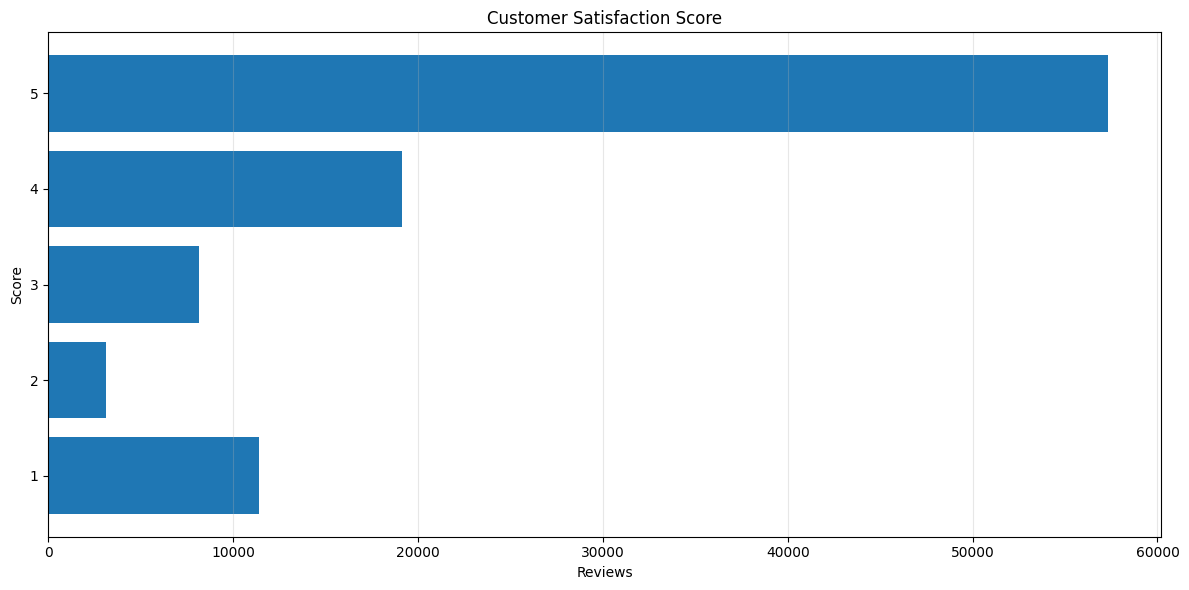

In [16]:
plt.figure(figsize=(12, 6))

plt.barh(reviews["review_score"], reviews["reviews"])

plt.title("Customer Satisfaction Score")
plt.xlabel("Reviews")
plt.ylabel("Score")

plt.grid(axis="x", alpha=0.3)


plt.tight_layout()
plt.show()

In [17]:
reviews["share"] = (reviews["reviews"] / reviews["reviews"].sum() * 100).round(2)

positive_reviews = reviews[reviews["review_score"] >= 4]["share"].sum()

negative_reviews = reviews[reviews["review_score"] <= 2]["share"].sum()

neutral_reviews = reviews[reviews["review_score"] == 3]["share"].sum()

print(f"Positive reviews: {positive_reviews:.1f}%")
print(f"Neutral reviews: {neutral_reviews:.1f}%")
print(f"Negative reviews: {negative_reviews:.1f}%")

Positive reviews: 77.1%
Neutral reviews: 8.2%
Negative reviews: 14.7%


**Insight:** Overall, customer satisfaction is high. 77.1% of reviews received four or five stars. Five-star reviews alone account for more than half of all customer reviews, indicating that the majority of customers had a positive shopping experience. Although the share of negative reviews is small (14.7%), one-star ratings are much more common than two-star ratings, suggesting that dissatisfied customers tend to report serious problems rather than minor inconveniences.

**Recommendation:** Maintain current level of customer service while conducting an in-depth analysis of one-star reviews to identify the root causes of dissatisfaction. Understanding whether these reviews are related to delivery quality, product quality or seller behavior will help you prioritize your efforts to improve customer service.

## Summary

The analysis shows that throughout the period under review, Olist demonstrated steady business growth. Both the number of orders fulfilled and revenue grew steadily thanks to strong performance in a small number of product categories and geographic regions. Delivery efficiency improved over time as sales volumes grew, and customer satisfaction remained high: more than 77% of reviews received four or five stars.

Overall, the business is showing healthy growth and a positive customer experience; however, further analysis should focus on identifying the factors driving regional variations in performance metrics and customer dissatisfaction.